In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [50]:
df = pd.read_csv('news.csv')

In [51]:
df.head(10)

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
5,6903,"Tehran, USA","\nI’m not an immigrant, but my grandparents ...",FAKE
6,7341,Girl Horrified At What She Watches Boyfriend D...,"Share This Baylee Luciani (left), Screenshot o...",FAKE
7,95,‘Britain’s Schindler’ Dies at 106,A Czech stockbroker who saved more than 650 Je...,REAL
8,4869,Fact check: Trump and Clinton at the 'commande...,Hillary Clinton and Donald Trump made some ina...,REAL
9,2909,Iran reportedly makes new push for uranium con...,Iranian negotiators reportedly have made a las...,REAL


In [52]:
df.drop(columns=["Unnamed: 0"],axis=1,inplace=True)

In [53]:
df.head(5)

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [54]:
df.shape

(6335, 3)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   label   6335 non-null   object
dtypes: object(3)
memory usage: 148.6+ KB


In [56]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(29)

In [58]:
df[df.duplicated(subset=['title', 'text'], keep=False)] \
    .sort_values(by=['title'])[:10]

,title,text,label
3216,An Open Letter to Black South African Police O...,Tweet Widget by Black Power Front \nWith stude...,FAKE
4885,An Open Letter to Black South African Police O...,Tweet Widget by Black Power Front \nWith stude...,FAKE
25,Anti-Trump forces seek last-ditch delegate revolt,Washington (CNN) The faction of the GOP that i...,REAL
5536,Anti-Trump forces seek last-ditch delegate revolt,Washington (CNN) The faction of the GOP that i...,REAL
6083,Biden Blames “Lazy American Women” For The Eco...,Email \n\nDemocratic Vice President Joe Biden ...,FAKE
5943,Biden Blames “Lazy American Women” For The Eco...,Email \n\nDemocratic Vice President Joe Biden ...,FAKE
5417,"Black Agenda Radio for Week of Nov. 7, 2016","News, information and analysis from the black ...",FAKE
1155,"Black Agenda Radio for Week of Nov. 7, 2016","News, information and analysis from the black ...",FAKE
2952,"Black Agenda Report for Week of Oct 31, 2016","News, information and analysis from the black ...",FAKE
2128,"Black Agenda Report for Week of Oct 31, 2016","News, information and analysis from the black ...",FAKE


In [59]:
df.drop_duplicates(inplace=True)

In [66]:
df = df.reset_index(drop=True)

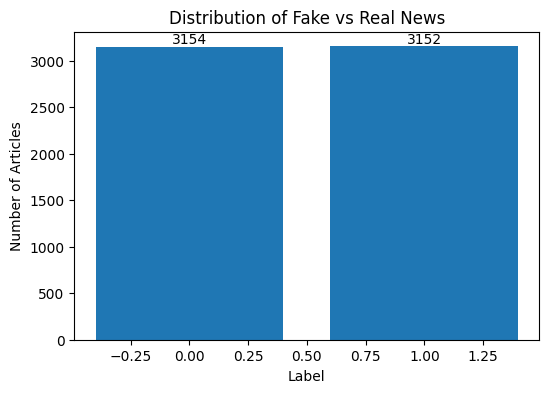

In [67]:
# plotting the distribution
label_counts = df['label'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(label_counts.index, label_counts)
plt.title("Distribution of Fake vs Real News")
plt.xlabel("Label")
plt.ylabel("Number of Articles")
for i, v in enumerate(label_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

In [68]:
# Very balanced dataset

In [69]:
df.describe()

,label
count,6306.000000
mean,0.500159
std,0.500040
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [70]:
# binary classification -> gotta encode the output by label encoder 1-> fake , 0 -> real
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label']= le.fit_transform(df['label'])


In [71]:
embedding_dim = 50
max_lelngth = 54
padding_type = 'post'
trunc_type='post'
oov_tok = '<OOV>'
training_size = 3000
test_portion=0.1

In [ ]:
# textual data -> to capture semantic meaning -> gotta convert to embeddings
# tokenization -> dividing corpus into small tokens
title=[]
text= []
labels= []

for i in range(training_size):
    title.append(df['title'][i])
    text.append(df['text'][i])
    title.append(df['label'][i])
    

title = []
text = []
labels = []

for i in range(training_size):
    title.append(df['title'][i])
    text.append(df['text'][i])
    labels.append(df['label'][i])

tokenizer1 = Tokenizer()
tokenizer1.fit_on_texts(title)
word_index1 = tokenizer1.word_index
vocab_size1 = len(word_index1)
sequences1 = tokenizer1.texts_to_sequences(title)
padded1 = pad_sequences(sequences1, padding=padding_type, truncating=trunc_type)
word_index1 = tokenizer1.word_index
vocab_size1=len(word_index1)
sequences1 = tokenizer1.texts_to_sequences(title)
padded1 = pad_sequences(sequences1,padding=padding_type,truncating=trunc_type)

In [ ]:
x=df.drop(columns=['label'])
y=df['label']
X_train,X_test , y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y) #stratify ensures proportion of fake and real stays same in both the data